In [39]:
# ==========================================
# Cell 1: Libraries & Data Preprocessing
# ==========================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score
from xgboost import XGBRegressor
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# Define file path
file_path = r"C:\Users\ozgur\Desktop\biodiversity_project_article\unito project part 1\project_dataset.xlsx"

try:
    df = pd.read_excel(file_path)
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print(f"ERROR: File not found at:\n{file_path}\nPlease check the path.")
    raise

# Column definitions
country_column = 'Country' 
target_column = 'BiodiversityIndex' 
continent_column = 'Continent'      

# Drop non-numeric columns for the model
X_data = df.drop(columns=[country_column, target_column, continent_column], errors='ignore')
X_data = X_data.select_dtypes(include=[np.number])

y = df[target_column]
groups = df[continent_column]
countries = df[country_column]

# Standardize
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_data), columns=X_data.columns)
feature_cols = X_scaled.columns.tolist()
X_tensor = torch.FloatTensor(X_scaled.values)

print(f"Preprocessing complete. Total Features: {len(feature_cols)}")

Dataset loaded successfully!
Preprocessing complete. Total Features: 37


In [40]:
# ==========================================
# Cell 2: Spatial Cross-Validation
# ==========================================
n_splits = min(5, groups.nunique())
gkf = GroupKFold(n_splits=n_splits)
model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

print(f"Starting Spatial Cross-Validation (n_splits={n_splits})...")
r2_scores = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X_scaled, y, groups=groups)):
    X_train, X_test = X_scaled.iloc[train_idx], X_scaled.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    model.fit(X_train, y_train)
    score = r2_score(y_test, model.predict(X_test))
    r2_scores.append(score)
    print(f"Fold {fold+1} R2: {score:.4f} | Test Continent(s): {groups.iloc[test_idx].unique()}")

print(f"Average Spatial CV R2 Score: {np.mean(r2_scores):.4f}")

# Train FINAL model for downstream analysis
final_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
final_model.fit(X_scaled, y)

Starting Spatial Cross-Validation (n_splits=5)...
Fold 1 R2: 0.1541 | Test Continent(s): ['WEST_AFRICA' 'SOUTH_AFRICA' 'CENTRAL_ASIA' 'WESTERN_EUROPE']
Fold 2 R2: -0.3673 | Test Continent(s): ['NORTH_AFRICA' 'BALKANS' 'SOUTH_EUROPE' 'WEST_ASIA']
Fold 3 R2: 0.4836 | Test Continent(s): ['CENTRAL_AFRICA' 'EAST_AFRICA' 'NORTH_AMERICA' 'CAUCASIANS' 'OCEANIA']
Fold 4 R2: 0.7373 | Test Continent(s): ['CARIBBEAN' 'NORTH_EUROPE' 'SOUTH_AMERICA' 'SOUTH_ASIA']
Fold 5 R2: 0.7001 | Test Continent(s): ['EAST_ASIA' 'CENTRAL_AMERICA' 'EAST_EUROPE' 'SOUTHEAST_ASIA']
Average Spatial CV R2 Score: 0.3416


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


Calculating SHAP Interaction Values (this may take a moment)...
High-resolution SHAP plot saved as 'SHAP_Interaction_HighRes.png'


<Figure size 1800x1200 with 0 Axes>

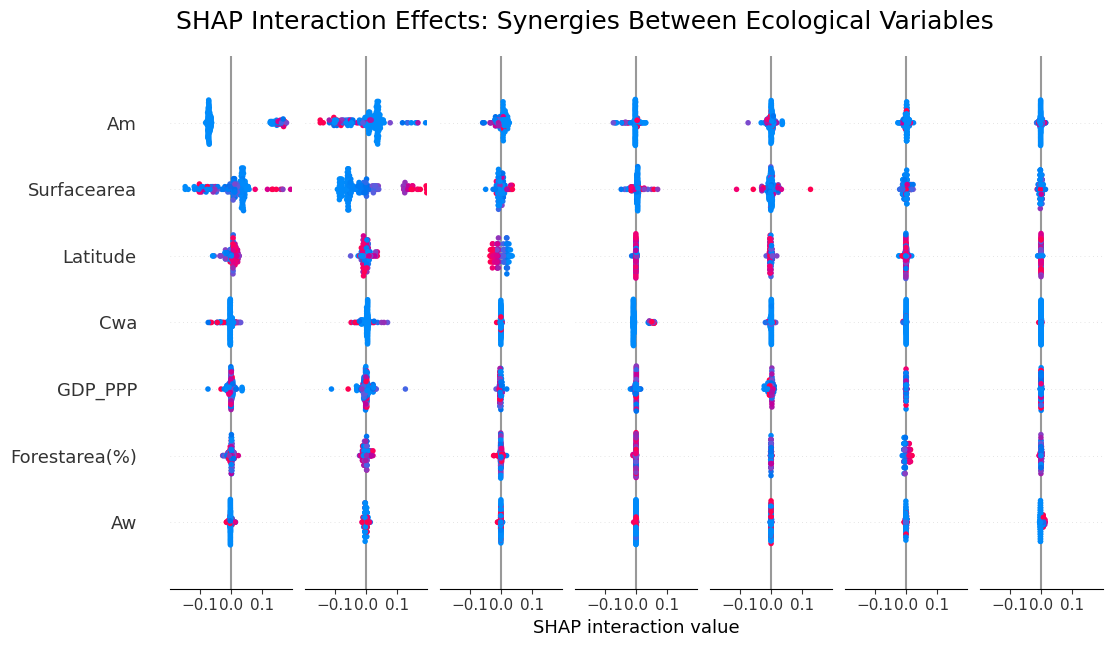

In [47]:
# ==========================================
# Cell 3: SHAP Interaction Analysis (Fixed Layout)
# ==========================================
import shap
import matplotlib.pyplot as plt

print("Calculating SHAP Interaction Values (this may take a moment)...")

# Initialize the explainer with the final trained model
explainer = shap.TreeExplainer(final_model) 
shap_interaction_values = explainer.shap_interaction_values(X_scaled)

plt.figure(figsize=(18, 12))

# We use show=False to modify the plot before displaying/saving
shap.summary_plot(shap_interaction_values, X_scaled, plot_type="interaction", show=False)

# Get the current figure to manipulate its axes
fig = plt.gcf()

# Loop through all axes (including the colorbar) and remove the cutoff text at the top
for ax in fig.axes:
    # This removes the variable name from the top of the color bar
    ax.set_title("") 

# Set a clean, perfectly centered main title
fig.suptitle("SHAP Interaction Effects: Synergies Between Ecological Variables", fontsize=18, y=0.95)

# Manually adjust margins instead of using tight_layout to prevent any clipping
plt.subplots_adjust(top=0.88, right=0.95)

# Save the plot
plt.savefig("SHAP_Interaction_HighRes.png", dpi=300, bbox_inches='tight')

print("High-resolution SHAP plot saved as 'SHAP_Interaction_HighRes.png'")
plt.show()

In [42]:
# ==========================================
# Cell 4: Autoencoder Training
# ==========================================
class RootCauseAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super(RootCauseAutoencoder, self).__init__()
        self.encoder = nn.Sequential(nn.Linear(input_dim, 16), nn.ReLU(), nn.Linear(16, 8), nn.ReLU())
        self.decoder = nn.Sequential(nn.Linear(8, 16), nn.ReLU(), nn.Linear(16, input_dim))
        
    def forward(self, x):
        return self.decoder(self.encoder(x))

ae_model = RootCauseAutoencoder(input_dim=len(feature_cols))
criterion = nn.MSELoss()
optimizer = optim.Adam(ae_model.parameters(), lr=0.001)

print("Training Root-Cause Autoencoder...")
ae_model.train()
for epoch in range(300):
    optimizer.zero_grad()
    loss = criterion(ae_model(X_tensor), X_tensor)
    loss.backward()
    optimizer.step()

Training Root-Cause Autoencoder...


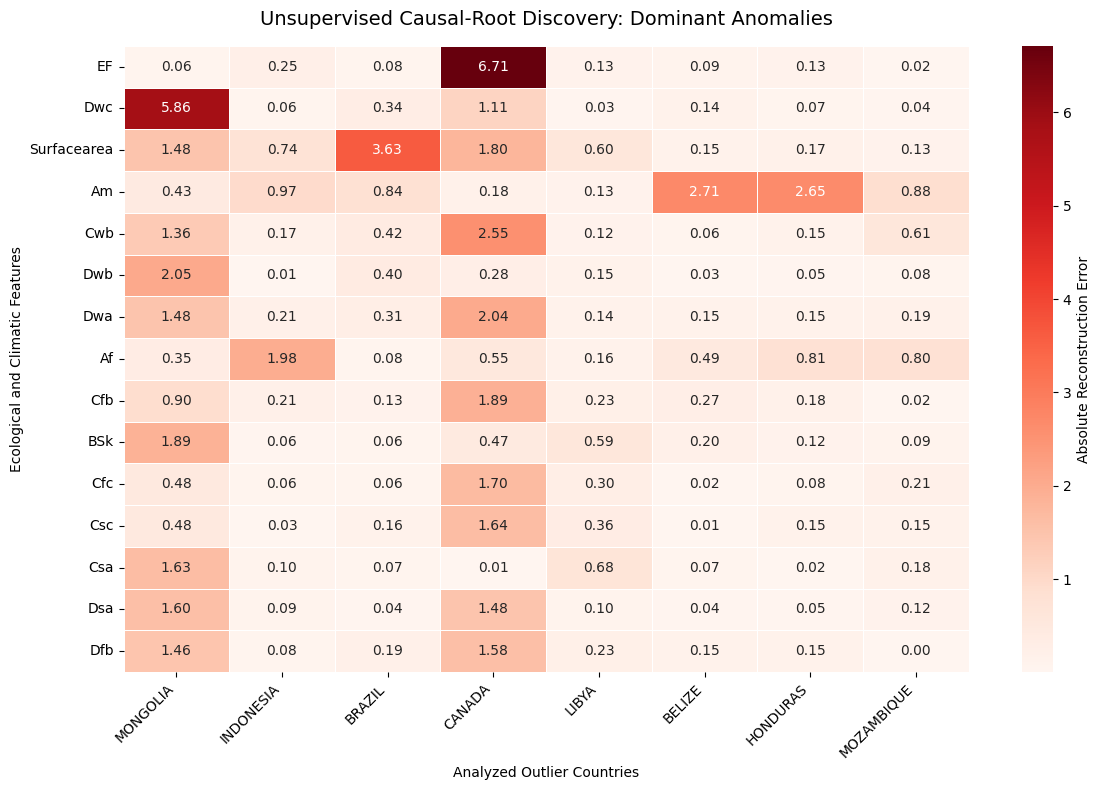

In [43]:
# ==========================================
# Cell 5: Causal-Root Discovery & Heatmap
# ==========================================
target_countries = ['Mongolia', 'Indonesia', 'Brazil', 'Canada', 'Libya', 'Belize', 'Honduras', 'Mozambique']
comprehensive_errors = pd.DataFrame(index=feature_cols)
ae_model.eval()

with torch.no_grad():
    for country in target_countries:
        try:
            idx = countries[countries.astype(str).str.contains(country, case=False, na=False)].index[0]
            country_data = torch.FloatTensor(X_scaled.iloc[idx].values).unsqueeze(0)
            errors = torch.abs(country_data - ae_model(country_data)).squeeze().numpy()
            comprehensive_errors[countries.iloc[idx]] = errors
        except IndexError:
            pass

top_features = comprehensive_errors.max(axis=1).sort_values(ascending=False).head(15).index
filtered_errors = comprehensive_errors.loc[top_features]

plt.figure(figsize=(12, 8))
sns.heatmap(filtered_errors, cmap='Reds', annot=True, fmt=".2f", linewidths=.5, cbar_kws={'label': 'Absolute Reconstruction Error'})
plt.title('Unsupervised Causal-Root Discovery: Dominant Anomalies', fontsize=14, pad=15)
plt.ylabel('Ecological and Climatic Features')
plt.xlabel('Analyzed Outlier Countries')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("Root_Cause_Heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

In [59]:
# ==========================================
# Cell 6: Multi-Country Policy Simulator (Fixed Z-Score Logic)
# ==========================================
import pandas as pd

def run_what_if_scenario(country_name, feature_to_modify, percentage_change):
    try:
        # Find the index of the queried country
        idx = countries[countries.astype(str).str.contains(country_name, case=False, na=False)].index[0]
        
        # 1. BUG FIX: Use X_data (RAW UNBIASED DATA) instead of X_scaled!
        original_unscaled = X_data.iloc[[idx]].copy()
        simulated_unscaled = original_unscaled.copy()
        
        # 2. Apply the percentage change to the physical, real-world data
        simulated_unscaled[feature_to_modify] *= (1 + percentage_change)
        
        # 3. Re-scale the raw data using the fitted StandardScaler for the model
        original_scaled_array = scaler.transform(original_unscaled)
        simulated_scaled_array = scaler.transform(simulated_unscaled)
        
        original_scaled = pd.DataFrame(original_scaled_array, columns=X_data.columns)
        simulated_scaled = pd.DataFrame(simulated_scaled_array, columns=X_data.columns)
        
        # 4. Generate predictions
        orig_pred = final_model.predict(original_scaled)[0]
        sim_pred = final_model.predict(simulated_scaled)[0]
        
        # Format and return the results
        return {
            "Country": countries.iloc[idx].upper(),
            "Feature": feature_to_modify,
            "Scenario Change": f"{'+' if percentage_change>0 else ''}{percentage_change*100}%",
            "Baseline Index": round(orig_pred, 4),
            "Simulated Index": round(sim_pred, 4),
            "Net Impact (Delta)": round(sim_pred - orig_pred, 4)
        }
    except IndexError:
        print(f"Warning: '{country_name}' not found in the dataset.")
        return None

# List of targeted outlier countries
target_countries = [
    'Mongolia', 'Indonesia', 'Brazil', 'Canada', 
    'Libya', 'Belize', 'Honduras', 'Mozambique'
]

print("Running Comprehensive Policy Simulation...\n")
scenario_results = []

# SCENARIO SETTINGS
target_feature = "Forestarea(%)" 
change_value = -0.30  # Let's test a massive 30% decline

for country in target_countries:
    result = run_what_if_scenario(country, target_feature, change_value)
    if result:
        scenario_results.append(result)

# Create and print the results table
results_df = pd.DataFrame(scenario_results)
print(f"--- SIMULATION RESULTS: {target_feature} at {change_value*100}% ---")
print(results_df.to_string(index=False))

# Save the output as an Excel file for the publication
results_df.to_excel("Simulation_Results_Corrected.xlsx", index=False)
print("\nResults saved locally as 'Simulation_Results_Corrected.xlsx'")

Running Comprehensive Policy Simulation...

--- SIMULATION RESULTS: Forestarea(%) at -30.0% ---
   Country       Feature Scenario Change  Baseline Index  Simulated Index  Net Impact (Delta)
  MONGOLIA Forestarea(%)          -30.0%          0.0677           0.0679              0.0002
 INDONESIA Forestarea(%)          -30.0%          0.8109           0.8052             -0.0056
    BRAZIL Forestarea(%)          -30.0%          0.9950           0.9882             -0.0068
    CANADA Forestarea(%)          -30.0%          0.1650           0.1706              0.0056
     LIBYA Forestarea(%)          -30.0%          0.0568           0.0665              0.0097
    BELIZE Forestarea(%)          -30.0%          0.1370           0.1401              0.0031
  HONDURAS Forestarea(%)          -30.0%          0.2416           0.2383             -0.0033
MOZAMBIQUE Forestarea(%)          -30.0%          0.2566           0.2561             -0.0005

Results saved locally as 'Simulation_Results_Corrected.xl

In [61]:
#VISUALIZATYION OF SCENARIO RESULTS

Generating Overlaid Bar Chart with Delta annotations...
Saved as 'Overlaid_Delta_BarChart.png'


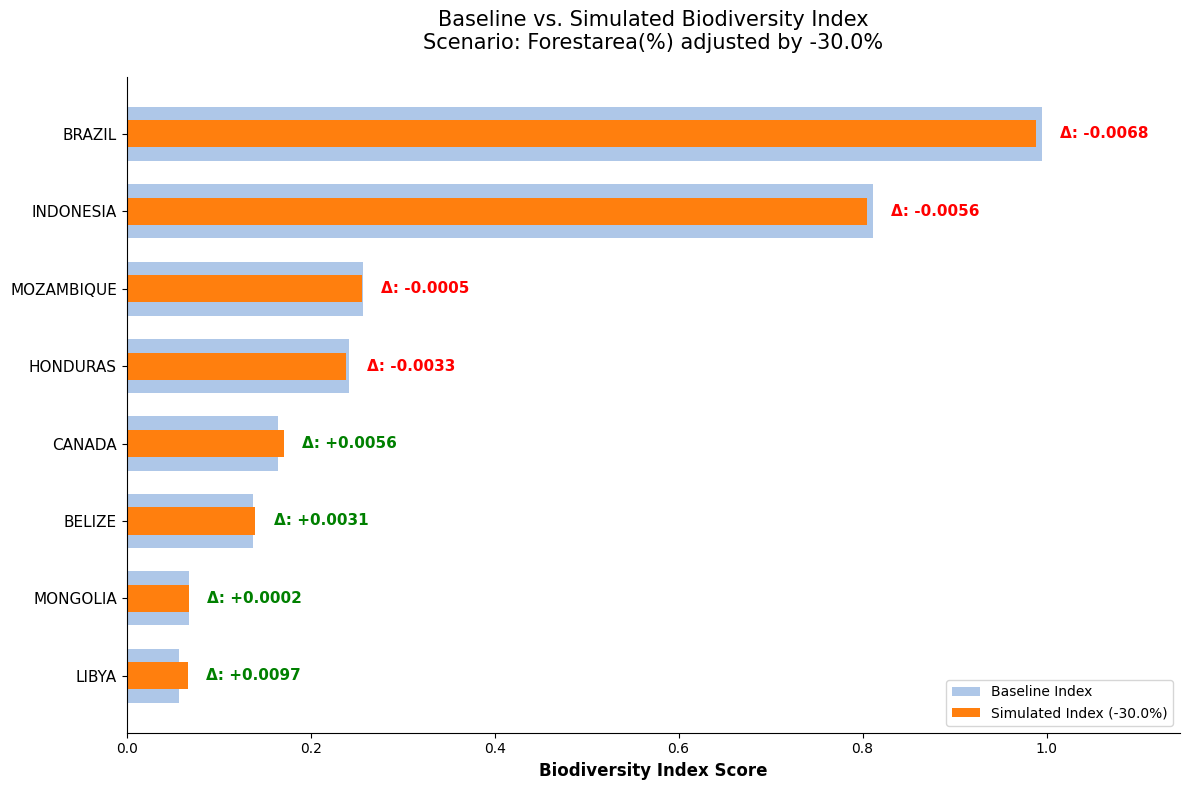

In [66]:
# ==========================================
# Visualization 1: Overlaid Bar Chart with Delta Annotation
# ==========================================
import matplotlib.pyplot as plt
import numpy as np

print("Generating Overlaid Bar Chart with Delta annotations...")

# Sort the dataframe by Baseline Index for a neat, stair-case visual flow
df_sorted = results_df.sort_values('Baseline Index', ascending=True).reset_index(drop=True)

# Initialize the plot figure
fig, ax = plt.subplots(figsize=(12, 8))
y_pos = np.arange(len(df_sorted))

# 1. Plot the Baseline Index (Thicker, lighter blue in the background)
ax.barh(
    y_pos, 
    df_sorted['Baseline Index'], 
    height=0.7, 
    color='#aec7e8', # Light blue
    label='Baseline Index'
)

# 2. Plot the Simulated Index (Thinner, orange overlaid on top)
ax.barh(
    y_pos, 
    df_sorted['Simulated Index'], 
    height=0.35, 
    color='#ff7f0e', # Orange
    label=f'Simulated Index ({change_value*100}%)'
)

# 3. Add the Delta text at the end of each bar
for i in range(len(df_sorted)):
    baseline = df_sorted['Baseline Index'][i]
    simulated = df_sorted['Simulated Index'][i]
    delta = df_sorted['Net Impact (Delta)'][i]
    
    # Find the maximum length to know where to place the text
    max_val = max(baseline, simulated)
    
    # Determine the color of the text based on the impact
    if delta > 0:
        text_color = 'green'
        sign = '+'
    elif delta < 0:
        text_color = 'red'
        sign = ''
    else:
        text_color = 'gray'
        sign = ''
        
    # Add the text annotation slightly to the right of the longest bar
    ax.text(
        max_val + 0.02,  # X position (padding)
        i,               # Y position
        f"Δ: {sign}{delta:.4f}", 
        va='center', 
        color=text_color, 
        fontweight='bold', 
        fontsize=11
    )

# Formatting the axes and labels for publication readiness
ax.set_yticks(y_pos)
ax.set_yticklabels(df_sorted['Country'], fontsize=11)
ax.set_xlabel('Biodiversity Index Score', fontsize=12, fontweight='bold')

# Dynamic X-axis limit to ensure the text annotations are not cut off
max_x = df_sorted[['Baseline Index', 'Simulated Index']].max().max()
ax.set_xlim(0, max_x + 0.15) 

# Clean up top and right borders (spines) for a modern look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title(f'Baseline vs. Simulated Biodiversity Index\nScenario: {target_feature} adjusted by {change_value*100}%', fontsize=15, pad=20)
plt.legend(loc='lower right', frameon=True)

plt.tight_layout()

# Save the high-resolution image
plt.savefig("Overlaid_Delta_BarChart.png", dpi=300, bbox_inches='tight')
print("Saved as 'Overlaid_Delta_BarChart.png'")

plt.show()